In [1]:
import fitsio as fio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from pathlib import Path
from pycorr import TwoPointCorrelationFunction

import scripts.statistics.corrutils as cu
import scripts.statistics.cosmtools as ct
import importlib

In [2]:
importlib.reload(cu)
ROOT = Path('../crosscorr/run14/')
TARGET = Path('ELGnotqso')
file_reader = cu.CorrFileReader(ROOT)

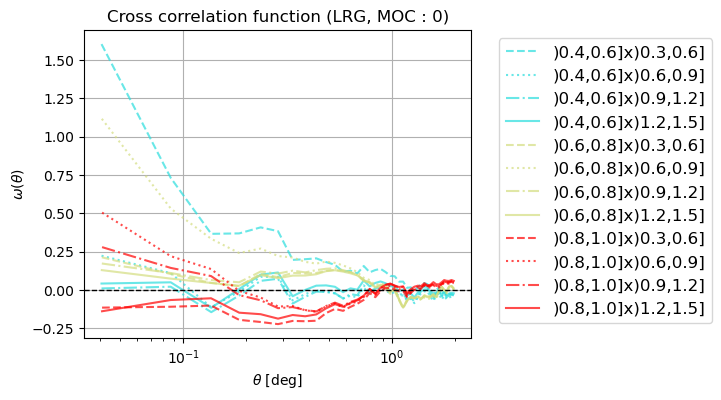

In [3]:
bhsc = file_reader.get_bins('hsc')
btgt = file_reader.get_bins('lrg')
tgt = 'LRG'
moc_idx = 0

cmap = plt.get_cmap('rainbow')
plt.figure(figsize=(5, 4))

ax = plt.gca()
for i in range(1, len(btgt)):
    for j in range(1, len(bhsc)):
        result = TwoPointCorrelationFunction.load(
            file_reader.get_file(i, j, moc_idx, tgt)
            )
        ls = '-' 
        if j == 1:
            ls = '--'
        if j == 2:
            ls = ':'
        if j == 3:
            ls = '-.'
        ax.plot(
            result.sep, 
            result.corr, 
            alpha=0.7,
            linestyle=ls,
            label=f'){btgt[i-1]:.1f},{btgt[i]:.1f}]x){bhsc[j-1]:.1f},{bhsc[j]:.1f}]',
            color=cmap(i/(len(btgt)-1)),
            )

ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\omega(\theta)$')
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
ax.set_title(f'Cross correlation function ({tgt}, MOC : {moc_idx})', fontsize=12)

#ax.set_yscale('log')
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.xscale('log')

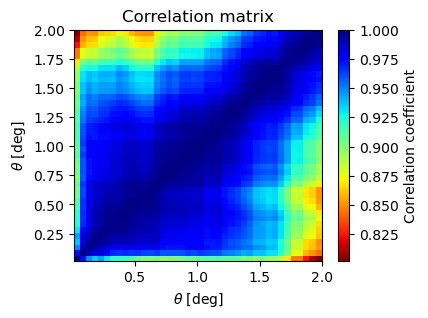

In [19]:
from pycorr import utils
importlib.reload(cu)
result_file = cu.CorrFileReader('../crosscorr/run15/').get_cov_result(1, 2, moc_idx, tgt)[0]
result = TwoPointCorrelationFunction.load(result_file)
sep = result.sep
cov = result.cov()

corrcoef = utils.cov_to_corrcoef(result.cov())

fig = plt.figure(figsize=(4, 3))
ax = plt.gca()
ax.pcolor(sep, sep, corrcoef.T, cmap=plt.get_cmap('jet_r'))
ax.set_title('Correlation matrix')
fig.colorbar(ax.collections[0], ax=ax, label='Correlation coefficient')
ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\theta$ [deg]')
plt.show()

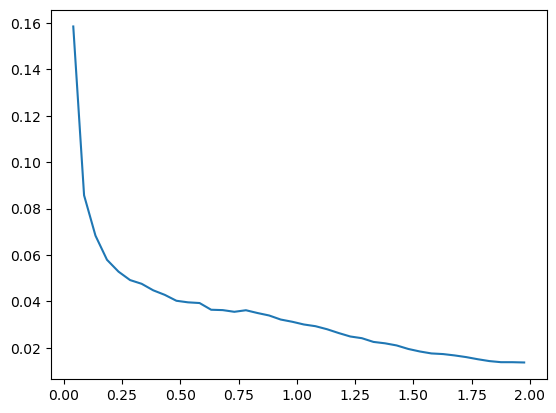

In [18]:
plt.plot(result.sep, result.corr, label='cov[0, 0]')

mid_z : 0.8539.39
mid_z : 0.9540.67
mid_z : 1.0541.64
mid_z : 1.1542.37
mid_z : 1.2542.89
mid_z : 1.3543.24
mid_z : 1.4543.46
mid_z : 1.5543.56


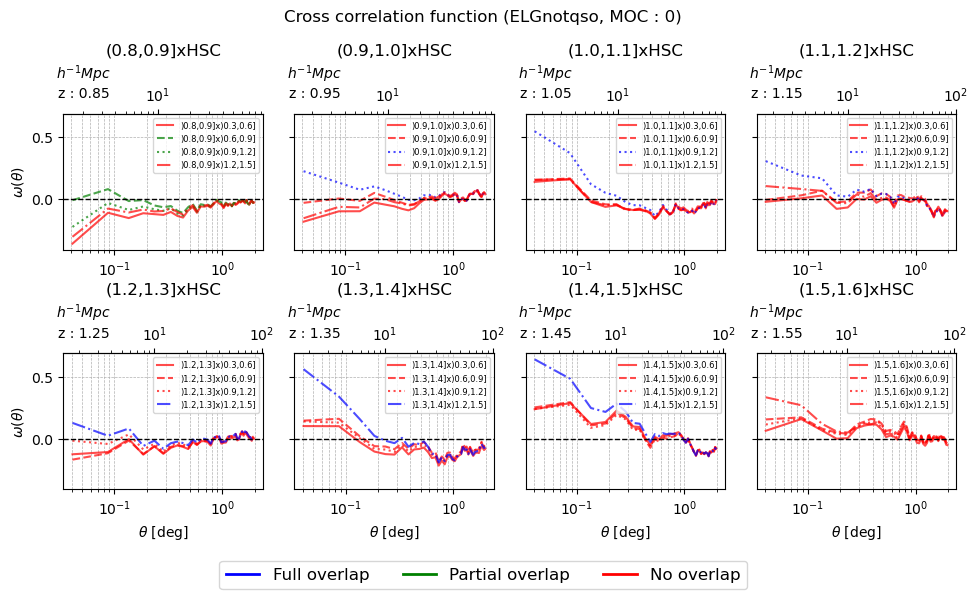

In [56]:
bhsc = file_reader.get_bins('hsc')
btgt = file_reader.get_bins('elg')
tgt = 'ELGnotqso'
moc_idx = 0

cmap = plt.get_cmap('rainbow')
fig, axs = plt.subplots(2, 4, sharey=True, figsize=(10, 6))

axs = axs.flatten()

for i, ax in enumerate(axs, start=1):
    for j in range(1, len(bhsc)):
        result = TwoPointCorrelationFunction.load(
            file_reader.get_file(i, j, moc_idx, tgt)
        )
        
        # Define bin edges
        btgt_min, btgt_max = btgt[i-1], btgt[i]
        bhsc_min, bhsc_max = bhsc[j-1], bhsc[j]

        # Check overlap conditions
        if bhsc_min <= btgt_min and bhsc_max >= btgt_max:
            color = 'blue'  # Full overlap
        elif bhsc_max <= btgt_min or bhsc_min >= btgt_max:
            color = 'red'   # No overlap
        else:
            color = 'green' # Partial overlap
        ls = '-' 
        if j == 2:
            ls = '--'
        if j == 3:
            ls = ':'
        if j == 4:
            ls = '-.'
        ax.plot(
            result.sep, 
            result.corr, 
            alpha=0.7,
            linestyle=ls,
            label=f'){btgt[i-1]:.1f},{btgt[i]:.1f}]x){bhsc[j-1]:.1f},{bhsc[j]:.1f}]',
            color=color,
            )
        if i > 4:
            ax.set_xlabel(r'$\theta$ [deg]')
        if i == 1 or i == 5:
            ax.set_ylabel(r'$\omega(\theta)$')
        if j == len(bhsc)-1:
            ax.grid(True, which='both', linestyle='--', lw=0.5)
            ax.set_xscale('log')
            ax.axhline(0, color='k', linestyle='--', lw=1)
            ax.set_title(f'({btgt[i-1]:.1f},{btgt[i]:.1f}]xHSC', fontsize=12)
            ax.legend(loc='upper right', fontsize=6)

            mid_z = (btgt[i-1] + btgt[i]) / 2
            tohMpc = lambda x, z=mid_z: ct.arcsec2hMpc(x * 3600, z=z)
            toArcsec = lambda theta, z=mid_z: ct.hMpc2arcsec(theta, z=z) / 3600
            print(f'mid_z : {mid_z:.2f}' + f'{tohMpc(1):.2f}')

            secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
            secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz : {mid_z:.2f}\n')
            secax.xaxis.set_label_coords(0.1, 0)

fig.suptitle(f'Cross correlation function ({tgt}, MOC : {moc_idx})', fontsize=12)
fig.tight_layout()

# overlap types
custom_lines = [
    mlines.Line2D([0], [0], color='blue', lw=2),
    mlines.Line2D([0], [0], color='green', lw=2),
    mlines.Line2D([0], [0], color='red', lw=2)
    ]
fig.legend(
    custom_lines, 
    [
        'Full overlap', 
        'Partial overlap', 
        'No overlap'
        ], 
    loc='lower center', 
    ncol=3, 
    bbox_to_anchor=(0.5, 0), 
    fontsize=12
    )
plt.subplots_adjust(bottom=0.18)

In [15]:
files = cu.fetch_desi_files('ELGnotqso', randoms=True)
btgt = file_reader.get_bins('elg')

z_per_z_bin = []
for f in files[:2]:
    try:
        with fio.FITS(f, 'r') as hdul:
            data = np.array(hdul[1].read(columns='Z'))
            print(data[:10])
            z_per_z_bin.extend(np.digitize(data, btgt, right=True))
            print(f"File: {f.stem}, Number of rows: {len(data)}")
    except Exception as e:
        print(f"Error reading file {f.stem}: {e}")

[0.87462935 0.97988902 1.34145495 0.80153387 1.0307199  0.88014099
 1.35565704 1.12549341 0.8690892  1.04872632]
File: ELGnotqso_4_clustering.ran, Number of rows: 25878470
[1.13777836 0.9251811  1.34804316 0.85013647 0.99332739 1.21299459
 1.32440692 0.87464542 1.03764136 1.36090095]
File: ELGnotqso_14_clustering.ran, Number of rows: 25880985


Text(0.5, 1.0, 'Redshift distribution of first\n2 random files ELGnotqso, subsampled x100')

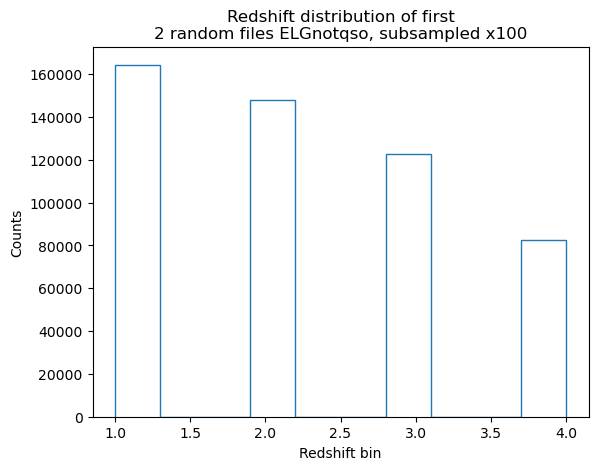

In [11]:
plt.hist(z_per_z_bin[0::100], histtype='step', lw=2)
plt.xlabel('Redshift bin')
plt.ylabel('Counts')
plt.title('Redshift distribution of first\n2 random files ELGnotqso, subsampled x100')

In [16]:
table = fio.FITS(Path(
                    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
                    ))

In [18]:
pz = table[1]['dnnz_photoz_best'].read()

Text(0.5, 1.0, 'Photo-z distribution (HSC)')

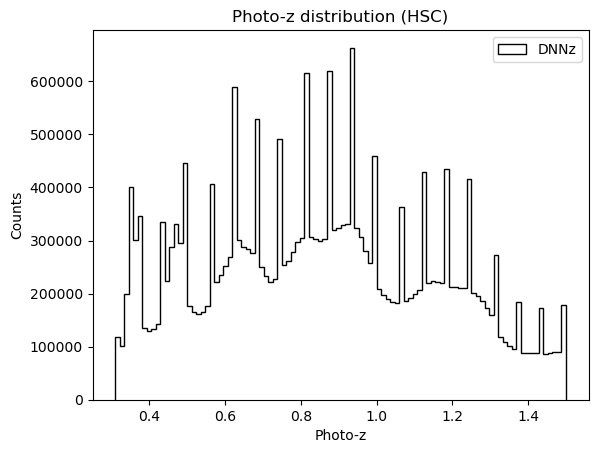

In [19]:
plt.hist(pz, bins=100, histtype='step', color='k', lw=2, label='DNNz')
plt.xlabel('Photo-z')
plt.ylabel('Counts')
plt.legend()
plt.title('Photo-z distribution (HSC)')

In [ ]:
import fitsio as fio
import os

os.listdir('/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/')

In [82]:
tbl = fio.FITS(
    '/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_clustering.dat.fits'
    )

In [83]:
sz = tbl[1]['Z'].read()

In [87]:
min(sz), max(sz)

(0.8000000181478555, 1.5999997110135349)

In [ ]:
len(sz)
bins_bgs = np.arange(0, 0.6, 0.1) # 0 < z < 0.6
bins_lrg = np.arange(0.4, 1.2, 0.1) # 0.4 < z < 1
bhsc = np.arange(0.8, 1.7, 0.1) # 0.6 < z < 1.6 => 0.8 < z < 1.6 in redshift distribution
bins_qso = np.arange(0.8, 3.4, 0.1) # 0.9 < z < 2.1

Text(0.5, 1.0, 'ELGnotqso redshift distribution')

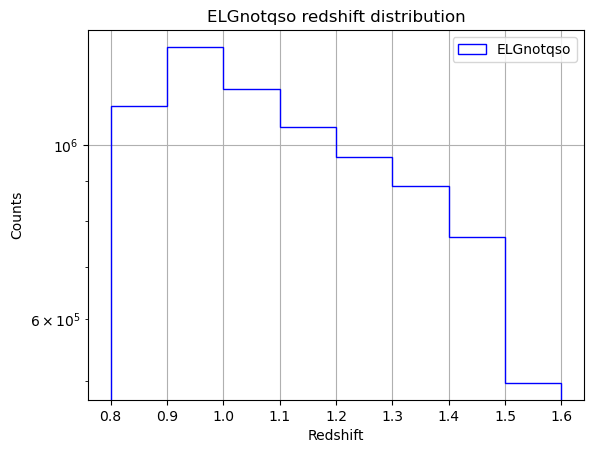

In [ ]:
plt.hist(sz, bins=bhsc, histtype='step', color='blue', lw=2, label='ELGnotqso')
plt.legend()
plt.yscale('log')
plt.ylabel('Counts')
plt.xlabel('Redshift')
plt.grid()
plt.title('ELGnotqso redshift distribution')

In [20]:
cat = fio.FITS(
    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
    )
cat[1].get_colnames()
pz = cat[1]['dnnz_photoz_best'].read()

1.5 0.31


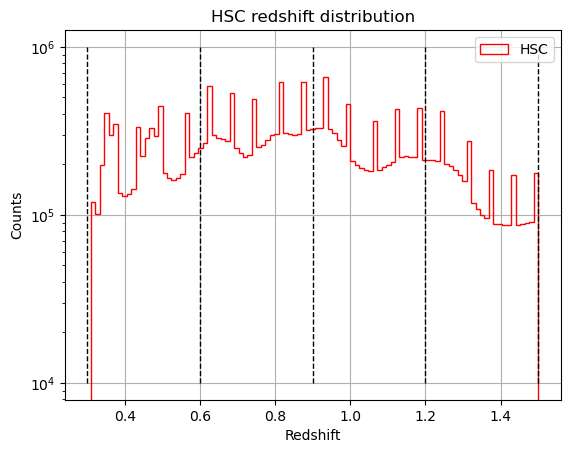

In [26]:
#bins_hsc = np.arange(0.3, 1.8, 0.3)
plt.hist(pz, bins=100, histtype='step', color='red', lw=2, label='HSC')
plt.vlines(
    [0.3, 0.6, 0.9, 1.2, 1.5], 
    ymin=1e4, ymax=1e6,
    color='black', linestyle='--', lw=1
    )
plt.legend()
plt.yscale('log')
plt.ylabel('Counts')
plt.xlabel('Redshift')
plt.grid()
plt.title('HSC redshift distribution')
print(max(pz), min(pz))